# E31 · The Indian buffet process: latent binary features

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Handwritten digits of the UCI "optdigits" collection (Alpaydin & Kaynak 1998): 300 training digits by 30 writers, 200 test digits by 13 *other* writers, 8 x 6 pixels of ink counts |
| **You will learn** | The Indian buffet process (IBP) as customers and dishes, as stick-breaking and as the limit of a finite beta-Bernoulli model · why $K_+ \sim \text{Poisson}(\alpha H_N)$ · the linear-Gaussian latent feature model $X = ZA + E$ and its collapsed likelihood · a collapsed Gibbs sampler in NumPy with new-dish proposals, rank-one updates and a brute-force correctness test · why the noise level, not $\alpha$, decides the number of features · Gibbs chains stuck in different modes, and why random split-merge moves do not rescue them · label-free summaries: $K_+$, log joint, the shared-feature matrix, feature matching across draws · the same model in PyMC with the binary matrix summed out over $2^K$ patterns, a start that collapses to "no features", and where it stops scaling · PPC and held-out completion of half-digits against probabilistic PCA |

E26 gave every data point **one** cluster out of an unbounded number. E22 gave every data point
a few **continuous** factor scores. The Indian buffet process sits between the two: every data
point owns a **set** of binary features, out of an unbounded supply, and features are shared
across data points. A handwritten 9 might own "a closed loop at the top" (shared with 8 and 0)
and "a stroke down the right side" (shared with 4, 3 and 7); a patient might own several
co-occurring conditions; a document several topics. The IBP is the prior that says how many
features there are and how they are shared, without fixing either in advance.

The data are small grayscale images, because the learned features can be *looked at*: each one
is an image that gets added to the digits that own it. The honest summary is mixed, and the
lessons are mostly about that mix. The prior on the number of features matters much less than
the noise level, which acts as a resolution knob. A Gibbs sampler over a binary matrix gets
stuck. The PyMC version, which sums the binary matrix out, is exact but exponential in the
number of features. The learned features give the best point predictions of missing
half-digits but not the best predictive density.

In [1]:
import itertools
import logging
import math
import time
from collections import Counter

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from scipy import stats
from scipy.special import gammaln, logsumexp

from pymc_challenges import data

RANDOM_SEED = 2005
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8a5cc2"
CHAIN_COLORS = [BLUE, ORANGE, AQUA, PURPLE]
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data

NIST scanned forms filled in by 43 people. Each digit was normalised to a 32 x 32 bitmap and the
bitmap was counted in 4 x 4 blocks, so every image is 8 x 8 pixels holding an ink count from 0
to 16. The UCI training file has 30 writers and the test file 13 different ones: a held-out
test of new *writers*, not just new digits.

In [2]:
data.describe("optdigits_train")
data.describe("optdigits_test")
train_raw = data.load("optdigits_train")
test_raw = data.load("optdigits_test")
print(train_raw.shape, test_raw.shape)

pix_train = train_raw.iloc[:, :64].to_numpy().reshape(-1, 8, 8) / 16
pix_test = test_raw.iloc[:, :64].to_numpy().reshape(-1, 8, 8) / 16
print("pixel sd by column (all training digits):", pix_train.std(axis=(0, 1)).round(2))

optdigits_train: 3823 handwritten digits by 30 writers: each 32x32 bitmap is counted in 4x4 blocks, giving 64 integer pixels 0-16 (8x8, row by row) followed by the digit 0-9. No header row.
  source: Alpaydin & Kaynak (1998), Optical Recognition of Handwritten Digits, UCI Machine Learning Repository (NIST forms preprocessed at Bogazici University).
  url:    https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tra
optdigits_test: 1797 digits by 13 writers who are NOT in optdigits_train; same 64 pixels (0-16) + digit layout.
  source: Alpaydin & Kaynak (1998), Optical Recognition of Handwritten Digits, UCI Machine Learning Repository: the writer-independent test set.
  url:    https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tes
(3823, 65) (1797, 65)
pixel sd by column (all training digits): [0.01 0.17 0.37 0.36 0.36 0.38 0.25 0.05]


The two outer columns are almost always blank (sd 0.01 and 0.05) and are dropped, leaving 8 x 6 =
48 pixels. We scale to ink in $[0, 1]$ and take 30 digits per class for training and 20 per class
from the test writers. The feature model below works with centred data (the average training
digit subtracted), so a feature is a *change* to the average digit: red where it adds ink, blue
where it removes it. The digit labels are never used for fitting, only to interpret the result.

training: 300 digits x 48 pixels; test: 200 digits by other writers
exact zeros: 32% of pixels; pixel sd after centring: 0.31


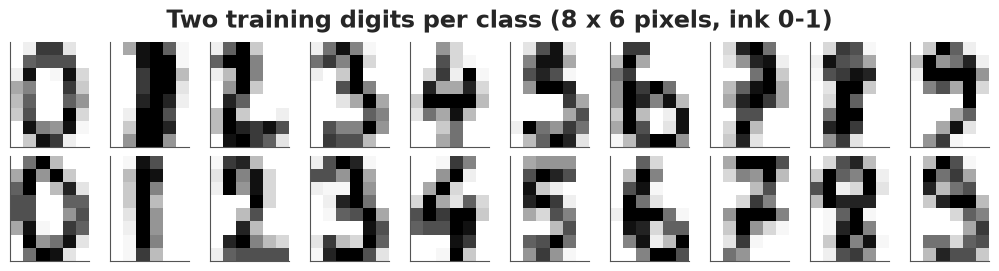

In [3]:
def take(pix, labels, per_class, rng):
    idx = np.concatenate([rng.choice(np.flatnonzero(labels == d), per_class, replace=False)
                          for d in range(10)])
    return pix[idx][:, :, 1:7].reshape(len(idx), -1), labels[idx]  # drop the blank border columns


Xraw, digit = take(pix_train, train_raw[64].to_numpy(), 30, rng)
Xraw_test, digit_test = take(pix_test, test_raw[64].to_numpy(), 20, rng)
mu = Xraw.mean(0)
X, X_test = Xraw - mu, Xraw_test - mu
N, D = X.shape
SHAPE = (8, 6)
print(f"training: {N} digits x {D} pixels; test: {len(X_test)} digits by other writers")
print(f"exact zeros: {(Xraw == 0).mean():.0%} of pixels; pixel sd after centring: {X.std():.2f}")

fig, axes = plt.subplots(2, 10, figsize=(10, 2.6))
for d in range(10):
    for r in range(2):
        ax = axes[r, d]
        ax.imshow(Xraw[np.flatnonzero(digit == d)[r]].reshape(SHAPE), cmap="Greys", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Two training digits per class (8 x 6 pixels, ink 0-1)");

## 2 · The Indian buffet process prior

### Customers and dishes

Griffiths & Ghahramani's (2005, 2011) metaphor. Customer 1 walks into a buffet and takes a
Poisson($\alpha$) number of dishes. Customer $i$ takes each dish already tried with probability
$m_k / i$, where $m_k$ is the number of earlier customers who took it (popular dishes stay
popular), and then tries a Poisson($\alpha / i$) number of new dishes. Customers are data
rows, dishes are features, and the result is a binary matrix $Z$ with $N$ rows and a random
number $K_+$ of non-empty columns. Sorting the columns by the binary number their entries form
(the *left-ordered form*) gives the usual staircase picture.

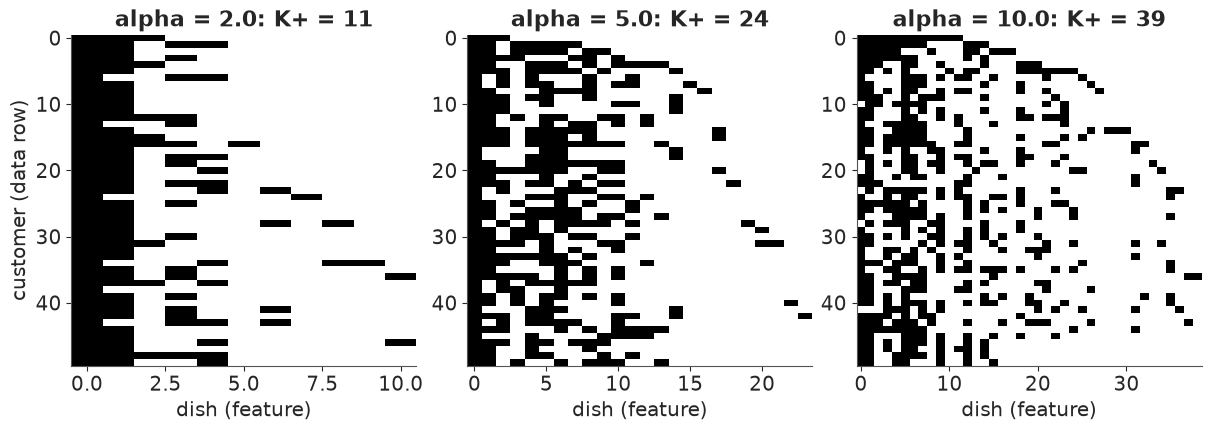

In [4]:
def ibp_sample(alpha, n, rng):
    """Customers and dishes: returns an n x K+ binary matrix."""
    dishes = []  # list of owner lists
    for i in range(1, n + 1):
        for owners in dishes:
            if rng.random() < len(owners) / i:
                owners.append(i - 1)
        for _ in range(rng.poisson(alpha / i)):
            dishes.append([i - 1])
    Z = np.zeros((n, len(dishes)), int)
    for k, owners in enumerate(dishes):
        Z[owners, k] = 1
    return Z


def left_ordered(Z):
    """Sort columns by the binary number formed by their rows (Griffiths & Ghahramani's lof)."""
    keys = [tuple(Z[:, k]) for k in range(Z.shape[1])]
    return Z[:, sorted(range(Z.shape[1]), key=lambda k: keys[k], reverse=True)]


fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, a in zip(axes, [2.0, 5.0, 10.0]):
    Zs = left_ordered(ibp_sample(a, 50, rng))
    ax.imshow(Zs, cmap="Greys", aspect="auto", interpolation="nearest")
    ax.set(title=f"alpha = {a}: K+ = {Zs.shape[1]}", xlabel="dish (feature)")
axes[0].set_ylabel("customer (data row)");

Three facts follow from the construction, and all three are worth knowing before any data:

- each row owns Poisson($\alpha$) features: the number of features *per row* does not grow
  with $N$;
- the total number of features is $K_+ \sim \text{Poisson}(\alpha H_N)$ with
  $H_N = \sum_{i=1}^N 1/i \approx \log N + 0.58$: it grows like $\log N$, like the number of
  clusters of a DP (E26);
- the process is exchangeable: the order of the customers does not matter, so any row can be
  treated as the last one. The Gibbs sampler below relies on this.

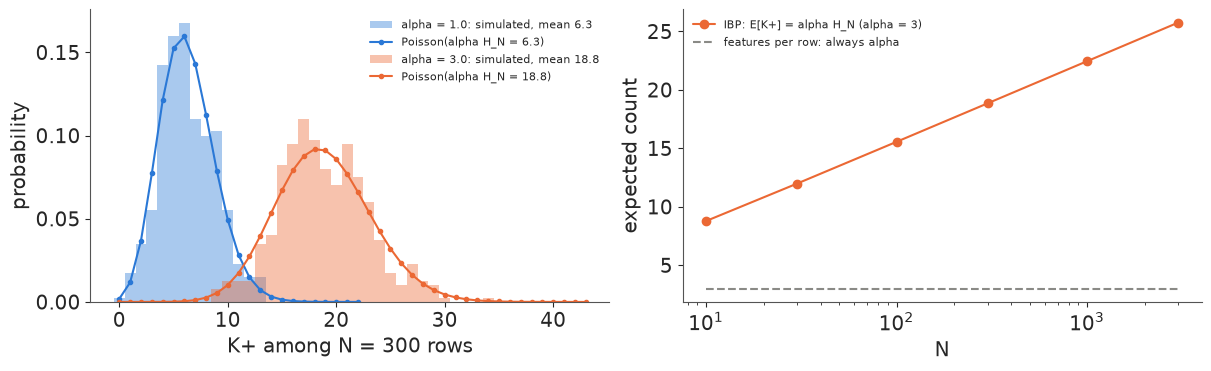

In [5]:
H_N = np.sum(1 / np.arange(1, N + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for a, c in zip([1.0, 3.0], [BLUE, ORANGE]):
    Ks = np.array([ibp_sample(a, N, rng).shape[1] for _ in range(400)])
    k = np.arange(Ks.max() + 10)
    axes[0].hist(Ks, bins=np.arange(-0.5, k.max()), density=True, color=c, alpha=0.4,
                 label=f"alpha = {a}: simulated, mean {Ks.mean():.1f}")
    axes[0].plot(k, stats.poisson(a * H_N).pmf(k), "o-", ms=3, color=c,
                 label=f"Poisson(alpha H_N = {a * H_N:.1f})")
axes[0].set(xlabel=f"K+ among N = {N} rows", ylabel="probability")
axes[0].legend(fontsize=8)

ns = np.array([10, 30, 100, 300, 1000, 3000])
axes[1].plot(ns, 3.0 * np.array([np.sum(1 / np.arange(1, n + 1)) for n in ns]), "o-", color=ORANGE,
             label="IBP: E[K+] = alpha H_N (alpha = 3)")
axes[1].plot(ns, np.full(len(ns), 3.0), "--", color=GREY, label="features per row: always alpha")
axes[1].set(xscale="log", xlabel="N", ylabel="expected count")
axes[1].legend(fontsize=8);

The simulation agrees with the Poisson law. For our $N = 300$, $H_N = 6.3$, so $\alpha = 1$
already expects about 6 features and $\alpha = 3$ about 19.

### Stick-breaking and the finite beta-Bernoulli model

Two other constructions give the same process and are what a PyMC model can use.

- **Finite beta-Bernoulli.** Give each of $K$ features a probability
  $\pi_k \sim \text{Beta}(\alpha/K, 1)$ and let $z_{ik} \sim \text{Bernoulli}(\pi_k)$. As
  $K \to \infty$ the distribution of the non-empty columns converges to the IBP (this is how
  Griffiths & Ghahramani derived it).
- **Stick-breaking** (Teh, Görür & Ghahramani 2007). Sorted in decreasing order, the feature
  probabilities are $\pi_{(k)} = \prod_{j \le k} \nu_j$ with $\nu_j \sim \text{Beta}(\alpha, 1)$.
  Unlike the DP's sticks (E26) these do not sum to one: each is a probability in its own right,
  and they shrink geometrically, $E[\pi_{(k)}] = (\alpha / (1 + \alpha))^k$. Truncating at $K$
  features drops everything past $\pi_{(K)}$, and the posterior of $\pi_{(K)}$ is the
  truncation check.

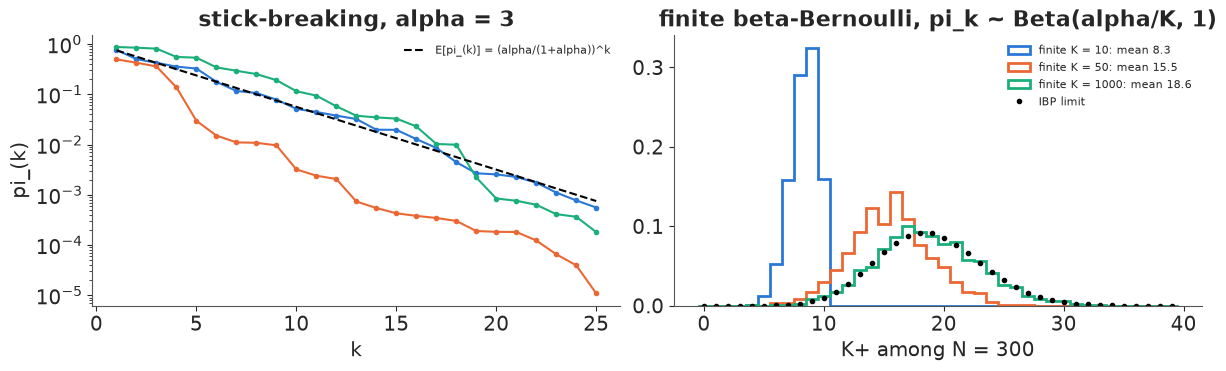

In [6]:
alpha_demo = 3.0
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
nu = rng.beta(alpha_demo, 1.0, size=(3, 25))
for j, p in enumerate(np.cumprod(nu, axis=1)):
    axes[0].plot(np.arange(1, 26), p, "o-", ms=3, color=CHAIN_COLORS[j])
kk = np.arange(1, 26)
axes[0].plot(kk, (alpha_demo / (1 + alpha_demo)) ** kk, "k--", label="E[pi_(k)] = (alpha/(1+alpha))^k")
axes[0].set(yscale="log", xlabel="k", ylabel="pi_(k)", title="stick-breaking, alpha = 3")
axes[0].legend(fontsize=8)

for Kfin, c in zip([10, 50, 1000], [BLUE, ORANGE, AQUA]):
    pis = rng.beta(alpha_demo / Kfin, 1.0, size=(2000, Kfin))
    Kplus = rng.binomial(1, 1 - (1 - pis) ** N).sum(1)  # features with at least one owner
    axes[1].hist(Kplus, bins=np.arange(-0.5, 40), density=True, histtype="step", lw=2, color=c,
                 label=f"finite K = {Kfin}: mean {Kplus.mean():.1f}")
k = np.arange(40)
axes[1].plot(k, stats.poisson(alpha_demo * H_N).pmf(k), "k.", label="IBP limit")
axes[1].set(xlabel=f"K+ among N = {N}", title="finite beta-Bernoulli, pi_k ~ Beta(alpha/K, 1)")
axes[1].legend(fontsize=8);

Left: three stick-breaking draws follow the geometric decay on average, with a lot of spread
between draws. Right: the finite model with $K = 10$ cannot have more than 10 features and
undershoots badly; $K = 50$ is still short; $K = 1000$ matches the IBP. A finite model is a
good approximation only when $K$ is well above the number of features the data will use - we
will run into this in section 7.

## 3 · A linear-Gaussian latent feature model, and a collapsed Gibbs sampler

The simplest likelihood for binary features (Griffiths & Ghahramani 2005) is linear-Gaussian:

$$X = Z A + E, \qquad a_{kd} \sim \text{Normal}(0, \sigma_A^2), \qquad e_{nd} \sim \text{Normal}(0, \sigma_X^2),$$

where row $k$ of $A$ is feature $k$'s image. A digit is the sum of the images of the features it
owns, plus noise. Because $A$ is Gaussian and enters linearly, it can be **integrated out**:

$$p(X \mid Z) = \frac{\exp\{-\tfrac{1}{2\sigma_X^2}\,\text{tr}(X^\top (I - Z M^{-1} Z^\top) X)\}}
{(2\pi)^{ND/2}\, \sigma_X^{(N-K)D}\, \sigma_A^{KD}\, |M|^{D/2}}, \qquad M = Z^\top Z + \tfrac{\sigma_X^2}{\sigma_A^2} I.$$

A **collapsed Gibbs sampler** then only has to move the binary matrix $Z$:

1. Treat row $i$ as the last customer. For a feature that other rows own ($m_{-i,k} > 0$), the
   prior is $P(z_{ik} = 1 \mid Z_{-i}) = m_{-i,k} / N$.
2. The likelihood of row $i$ given all other rows is a Gaussian predictive: with
   $P = M_{-i}^{-1}$ and $\bar A = P Z_{-i}^\top X_{-i}$ (the posterior mean of the features without
   row $i$), $x_i \sim \text{Normal}(z_i \bar A,\ \sigma_X^2 (1 + z_i P z_i^\top) I)$. Flipping one
   $z_{ik}$ changes the residual and the quadratic form $z P z^\top$ by rank-one amounts, so each
   flip costs $O(K)$ scalar arithmetic.
3. Features that only row $i$ owns (*singletons*) are resampled as "new dishes": their number has
   prior Poisson($\alpha/N$), and each one adds $\sigma_A^2$ to the predictive variance (its image
   has seen no other data), so the conditional over 0, 1, ..., 4 new dishes is exact.
4. $M^{-1}$ is kept up to date with Sherman-Morrison down- and up-dates when a row leaves and
   re-enters, so a sweep costs $O(N K^2 D)$ instead of $O(N K^4)$.

In [7]:
def collapsed_loglik(X, Z, sx, sa):
    """log p(X | Z, sigma_X, sigma_A) with the features A integrated out (Griffiths & Ghahramani 2011)."""
    N, D = X.shape
    Z = Z.astype(float)
    K = Z.shape[1]
    L = np.linalg.cholesky(Z.T @ Z + (sx / sa) ** 2 * np.eye(K))
    W = np.linalg.solve(L, Z.T @ X)
    return (-0.5 * N * D * np.log(2 * np.pi) - (N - K) * D * np.log(sx) - K * D * np.log(sa)
            - D * np.log(np.diag(L)).sum() - (np.sum(X * X) - np.sum(W * W)) / (2 * sx**2))


def log_ibp_prior(Z, alpha):
    """log P([Z] | alpha) of the left-ordered equivalence class (Griffiths & Ghahramani 2011)."""
    N = Z.shape[0]
    m = Z.sum(0)
    dup = Counter(Z[:, k].tobytes() for k in range(Z.shape[1]))
    return (Z.shape[1] * np.log(alpha) - sum(gammaln(v + 1) for v in dup.values())
            - alpha * np.sum(1 / np.arange(1, N + 1))
            + np.sum(gammaln(N - m + 1) + gammaln(m) - gammaln(N + 1)))


def gibbs_sweep(X, Z, alpha, sx, sa, rng, max_new=4):
    """One collapsed Gibbs sweep over the rows of Z (N x K, 0/1); returns Z without empty columns."""
    N, D = X.shape
    Z = Z.astype(float)
    r = (sx / sa) ** 2
    sx2, sa2, half_D = sx * sx, sa * sa, 0.5 * D
    Minv = np.linalg.inv(Z.T @ Z + r * np.eye(Z.shape[1]))  # recomputed every sweep: no drift
    B = Z.T @ X
    m = Z.sum(0)
    for i in range(N):
        zi, xi = Z[i].copy(), X[i]
        # 1. take row i out (Sherman-Morrison downdate of M^-1 = (Z'Z + r I)^-1)
        v = Minv @ zi
        P = Minv + np.outer(v, v) / (1.0 - zi @ v)
        B -= np.outer(zi, xi)
        m -= zi
        # 2. features that only row i has ("singletons") are resampled as new dishes in step 4
        keep = m > 0
        n_single = int((~keep).sum())
        if n_single:
            Z, P, B, m, zi = Z[:, keep], P[np.ix_(keep, keep)], B[keep], m[keep], zi[keep]
        K = len(m)
        # 3. flip each shared feature. Given the other rows, x_i ~ N(z Abar, s2(z) I) with
        #    s2(z) = sx^2 (1 + z P z) + n_single sa^2: two scalars carry the whole likelihood.
        Abar = P @ B
        resid = xi - zi @ Abar
        G = Abar @ Abar.T
        c, Pz = (Abar @ resid).tolist(), (P @ zi).tolist()
        rr, q = float(resid @ resid), float(zi @ P @ zi)
        Gd, Pd = np.diag(G).tolist(), np.diag(P).tolist()
        lp1, lp0 = np.log(m / N).tolist(), np.log1p(-m / N).tolist()
        u = np.log(rng.random(K)).tolist()
        z = zi.tolist()
        extra = n_single * sa2
        for k in range(K):
            s = 1.0 - 2.0 * z[k]  # +1: switch on, -1: switch off
            rr_f = rr - 2.0 * s * c[k] + Gd[k]
            q_f = q + 2.0 * s * Pz[k] + Pd[k]
            v_c, v_f = sx2 * (1.0 + q) + extra, sx2 * (1.0 + q_f) + extra
            ll_c = -half_D * math.log(v_c) - rr / (2.0 * v_c)
            ll_f = -half_D * math.log(v_f) - rr_f / (2.0 * v_f)
            d = (ll_f + (lp0[k] if z[k] else lp1[k])) - (ll_c + (lp1[k] if z[k] else lp0[k]))
            if u[k] < (-math.log1p(math.exp(-d)) if d > -30.0 else d):
                c = [a - s * g for a, g in zip(c, G[:, k].tolist())]
                Pz = [a + s * p for a, p in zip(Pz, P[:, k].tolist())]
                rr, q, z[k] = rr_f, q_f, 1.0 - z[k]
        zi = np.array(z)
        # 4. new dishes: prior Poisson(alpha / N); each adds sa^2 to the predictive variance
        kn = np.arange(max_new + 1)
        s2 = sx2 * (1 + q) + kn * sa2
        logw = kn * np.log(alpha / N) - gammaln(kn + 1) - half_D * np.log(s2) - rr / (2 * s2)
        knew = rng.choice(kn, p=np.exp(logw - logsumexp(logw)))
        if knew:
            Z = np.hstack([Z, np.zeros((N, knew))])
            P = np.block([[P, np.zeros((K, knew))], [np.zeros((knew, K)), np.eye(knew) / r]])
            B = np.vstack([B, np.zeros((knew, D))])
            m = np.concatenate([m, np.zeros(knew)])
            zi = np.concatenate([zi, np.ones(knew)])
        # 5. put row i back (Sherman-Morrison update)
        v = P @ zi
        Minv = P - np.outer(v, v) / (1.0 + zi @ v)
        B += np.outer(zi, xi)
        m += zi
        Z[i] = zi
    return Z[:, m > 0].astype(np.int8)

### Test the sampler against brute force

A sampler written by hand needs a test, and the IBP has a clean one: with three rows there are
only 7 possible non-empty columns, so the posterior over every multiset of columns can be
enumerated with the prior of the equivalence class (`log_ibp_prior` above, with its
$1 / \prod_h K_h!$ for identical columns) and the collapsed likelihood. We compare the exact
posterior of $K_+$ with a long Gibbs run.

In [8]:
def exact_Kplus(X, alpha, sx, sa, Kmax=8):
    """Posterior of K+ by enumerating every multiset of non-zero columns (tiny N only)."""
    types = [np.array(t, np.int8) for t in itertools.product([0, 1], repeat=X.shape[0]) if any(t)]
    logp = np.full(Kmax + 1, -np.inf)
    for K in range(Kmax + 1):
        for combo in itertools.combinations_with_replacement(range(len(types)), K):
            Z = np.column_stack([types[j] for j in combo]) if K else np.zeros((X.shape[0], 0), np.int8)
            logp[K] = np.logaddexp(logp[K], log_ibp_prior(Z, alpha) + collapsed_loglik(X, Z, sx, sa))
    return np.exp(logp - logsumexp(logp))


X_tiny = rng.normal(0, 2, size=(3, 2))
t0 = time.time()
p_exact = exact_Kplus(X_tiny, 1.5, 0.5, 1.0)
Z, K_tiny = np.ones((3, 1), np.int8), []
for _ in range(30000):
    Z = gibbs_sweep(X_tiny, Z, 1.5, 0.5, 1.0, rng, max_new=10)
    K_tiny.append(Z.shape[1])
p_gibbs = np.bincount(K_tiny[1000:], minlength=9)[:9] / len(K_tiny[1000:])
print(f"({time.time() - t0:.0f} s)")
print("K+          :", np.arange(9))
print("exact       :", p_exact.round(3))
print("Gibbs 29000 :", p_gibbs.round(3))

(7 s)
K+          : [0 1 2 3 4 5 6 7 8]
exact       : [0.    0.288 0.323 0.217 0.108 0.043 0.015 0.004 0.001]
Gibbs 29000 : [0.    0.277 0.326 0.221 0.109 0.047 0.014 0.004 0.001]


Exact and Gibbs agree to within Monte Carlo error. The test earned its place while this
notebook was written: a first version of the sampler removed row $i$'s singletons *before*
flipping its shared features, which silently conditions the flips on "row $i$ has no singletons",
and this comparison showed a sampler that put too little mass on large $K_+$. The fix is the
`extra` term in step 3: while the shared features are flipped, the current singletons stay in the
model and each contributes $\sigma_A^2$ of predictive variance.

### Hyperparameters and a chain runner

$\alpha$ has a conjugate update: with $\alpha \sim \text{Gamma}(1, 1)$ the posterior is
$\text{Gamma}(1 + K_+,\ 1 + H_N)$. The two scales get HalfNormal(1) priors and a random-walk
Metropolis step on the log scale, each proposal costing one collapsed likelihood (a $K \times K$
Cholesky). Every sweep records $K_+$, the hyperparameters, the collapsed log-likelihood and the
log joint $\log p(X \mid Z) + \log P([Z] \mid \alpha)$: all of them are label-free.

In [9]:
def run_chain(X, n_sweeps, rng, Z0=None, sx=0.25, sa=0.3, alpha=1.0, fix_sx=True, fix_alpha=False,
              a_prior=(1.0, 1.0), thin=5, burn=0):
    """Gibbs for Z, conjugate Gamma update for alpha, log-scale random-walk Metropolis for
    sigma_A (and sigma_X unless fixed), both with HalfNormal(1) priors."""
    N = X.shape[0]
    H = np.sum(1 / np.arange(1, N + 1))
    Z = np.ones((N, 1), np.int8) if Z0 is None else Z0.astype(np.int8)
    tr = {k: [] for k in ["K", "alpha", "sx", "sa", "loglik", "logjoint"]}
    kept = []
    for t in range(n_sweeps):
        Z = gibbs_sweep(X, Z, alpha, sx, sa, rng)
        if not fix_alpha:
            alpha = rng.gamma(a_prior[0] + Z.shape[1], 1 / (a_prior[1] + H))
        ll = collapsed_loglik(X, Z, sx, sa)
        for _ in range(3):
            for j in ((1,) if fix_sx else (0, 1)):
                prop = [sx, sa]
                prop[j] *= math.exp(0.05 * rng.normal())
                ll_p = collapsed_loglik(X, Z, *prop)
                cur = (sx, sa)[j]
                if math.log(rng.random()) < (ll_p - ll - 0.5 * (prop[j] ** 2 - cur**2)
                                             + math.log(prop[j] / cur)):
                    (sx, sa), ll = prop, ll_p
        for k, val in zip(tr, [Z.shape[1], alpha, sx, sa, ll, ll + log_ibp_prior(Z, alpha)]):
            tr[k].append(val)
        if t >= burn and (t - burn) % thin == 0:
            kept.append((Z.copy(), sx, sa, alpha))
    return {k: np.array(v) for k, v in tr.items()}, kept

## 4 · First fit: everything free

The natural first attempt learns $Z$, $\alpha$, $\sigma_A$ and the noise $\sigma_X$ together.

In [10]:
t0 = time.time()
tr_free, kept_free = run_chain(X, 300, np.random.default_rng(1), sx=0.5, sa=0.5, fix_sx=False, burn=200)
print(f"{time.time() - t0:.0f} s; last 100 sweeps: K+ = {tr_free['K'][-100:].mean():.0f}, "
      f"sigma_X = {tr_free['sx'][-100:].mean():.3f}, sigma_A = {tr_free['sa'][-100:].mean():.3f}, "
      f"alpha = {tr_free['alpha'][-100:].mean():.1f}")

11 s; last 100 sweeps: K+ = 90, sigma_X = 0.104, sigma_A = 0.117, alpha = 12.5


After 300 sweeps the chain holds about 90 features and has not clearly levelled off, while
$\sigma_X$ has fallen from 0.5 to 0.10 and $\alpha$ has risen to 12. Nothing is broken; the model is doing
what it was told. With independent Gaussian noise, anything the features do not explain is
called noise, so every extra feature that explains a quirk of a few digits buys a smaller
$\sigma_X$, which makes the next quirk worth a feature too. Ninety features for 300 digits is not
a parts-based description.

How much do the two knobs matter? Short runs with $\sigma_X$ held at five values, then with
$\sigma_X = 0.25$ and $\alpha$ held at four values spanning a factor of 500:

In [11]:
t0 = time.time()
sens = {}
for sx in [0.15, 0.2, 0.25, 0.3, 0.35]:
    tr_s, _ = run_chain(X, 200, np.random.default_rng(2), sx=sx)
    sens[("sigma_X", sx)] = tr_s["K"][100:]
for a in [0.1, 1.0, 10.0, 50.0]:
    tr_s, _ = run_chain(X, 200, np.random.default_rng(2), sx=0.25, alpha=a, fix_alpha=True)
    sens[("alpha", a)] = tr_s["K"][100:]
print(f"{time.time() - t0:.0f} s")
for key, Ks in sens.items():
    print(f"  {key[0]:8s} = {key[1]:5}: K+ mean {Ks.mean():5.1f}, range {Ks.min()}-{Ks.max()}")

41 s
  sigma_X  =  0.15: K+ mean  44.1, range 42-47
  sigma_X  =   0.2: K+ mean  26.8, range 26-28
  sigma_X  =  0.25: K+ mean  16.1, range 16-17
  sigma_X  =   0.3: K+ mean   7.9, range 7-9
  sigma_X  =  0.35: K+ mean   4.0, range 3-6
  alpha    =   0.1: K+ mean  11.0, range 11-11
  alpha    =   1.0: K+ mean  15.1, range 15-16
  alpha    =  10.0: K+ mean  18.7, range 17-21
  alpha    =  50.0: K+ mean  20.8, range 19-25


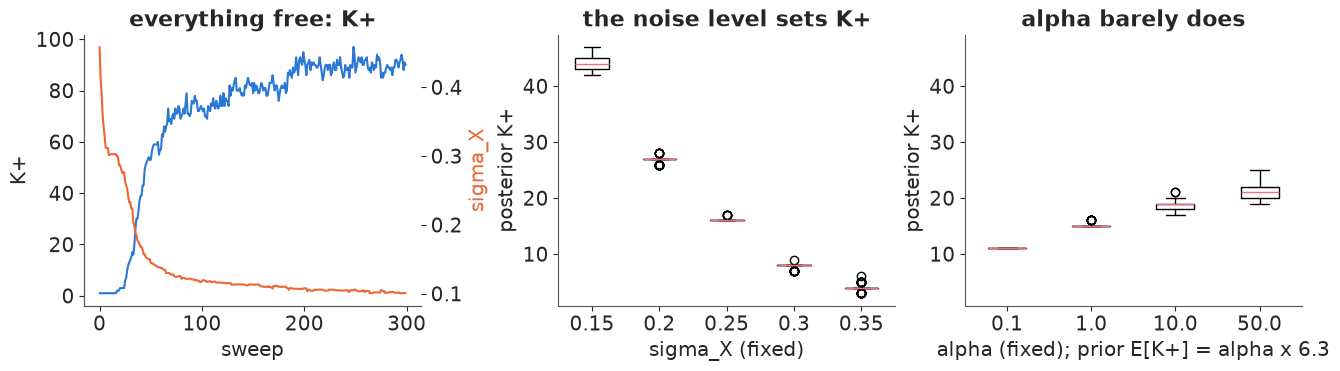

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(tr_free["K"], color=BLUE)
axes[0].set(xlabel="sweep", ylabel="K+", title="everything free: K+")
ax2 = axes[0].twinx()
ax2.plot(tr_free["sx"], color=ORANGE)
ax2.set_ylabel("sigma_X", color=ORANGE)
xs = [0.15, 0.2, 0.25, 0.3, 0.35]
axes[1].boxplot([sens[("sigma_X", s)] for s in xs], positions=range(len(xs)))
axes[1].set_xticks(range(len(xs)), [str(s) for s in xs])
axes[1].set(xlabel="sigma_X (fixed)", ylabel="posterior K+", title="the noise level sets K+")
al = [0.1, 1.0, 10.0, 50.0]
axes[2].boxplot([sens[("alpha", a)] for a in al], positions=range(len(al)))
axes[2].set_xticks(range(len(al)), [str(a) for a in al])
axes[2].set(xlabel="alpha (fixed); prior E[K+] = alpha x 6.3", ylabel="posterior K+",
            title="alpha barely does", ylim=axes[1].get_ylim());

Between $\sigma_X = 0.15$ and $0.35$ the number of features falls from about 44 to 4. Across
$\alpha$ from 0.1 to 50, a range over which the *prior* mean of $K_+$ goes from 0.6 to 315, the
posterior moves only from 11 to 21. **The noise level, not $\alpha$, sets the number of features**:
$\sigma_X$ is a resolution knob, and the IBP will resolve the digits into as many features as the
resolution asks for. $\alpha$ still matters at the margin, which is what one expects of a prior.

So we choose the resolution rather than let the likelihood choose it. An argument from how the
data were made: a pixel counts ink in a 4 x 4 block, and moving a one-pixel-wide pen stroke by
one bitmap pixel shifts up to 4 of the 16 counts, 0.25 on our scale. Setting $\sigma_X = 0.25$
says: *differences smaller than a one-pixel wobble of the pen are noise, not features.* That is a
modelling decision, and section 8 measures what it costs in prediction.

## 5 · The main fit: $\sigma_X = 0.25$, four chains

Four chains of 600 sweeps: two start from a single feature owned by everybody, two from 40
random features. The first 200 sweeps are warm-up.

In [13]:
SX = 0.25
inits = [None, None, (rng.random((N, 40)) < 0.2), (rng.random((N, 40)) < 0.2)]
t0 = time.time()
chains = [run_chain(X, 600, np.random.default_rng(10 + c), Z0=inits[c], sx=SX, burn=200)
          for c in range(4)]
print(f"4 chains x 600 sweeps: {time.time() - t0:.0f} s")
traces = {k: np.stack([c[0][k] for c in chains]) for k in chains[0][0]}

4 chains x 600 sweeps: 55 s


In [14]:
post = xr.Dataset({k: (("chain", "draw"), v[:, 200:]) for k, v in traces.items() if k != "sx"})
rhat, ess = az.rhat(post), az.ess(post)
print("label-free diagnostics over the 4 x 400 post-warm-up sweeps:")
for k in post.data_vars:
    print(f"  {k:9s} r_hat {float(rhat[k]):5.2f}   ess {float(ess[k]):6.0f}")
for c in range(4):
    print(f"chain {c}: K+ {traces['K'][c, 200:].mean():5.1f}   log joint {traces['logjoint'][c, 200:].mean():7.0f}"
          f" (sd {traces['logjoint'][c, 200:].std():3.0f})   alpha {traces['alpha'][c, 200:].mean():.2f}"
          f"   sigma_A {traces['sa'][c, 200:].mean():.3f}")

label-free diagnostics over the 4 x 400 post-warm-up sweeps:
  K         r_hat  3.95   ess      4
  alpha     r_hat  1.09   ess     31
  sa        r_hat  1.41   ess      8
  loglik    r_hat  2.06   ess      5
  logjoint  r_hat  1.72   ess      6
chain 0: K+  17.7   log joint    -558 (sd  21)   alpha 2.55   sigma_A 0.203
chain 1: K+  16.1   log joint    -629 (sd  29)   alpha 2.36   sigma_A 0.195
chain 2: K+  18.9   log joint    -602 (sd  53)   alpha 2.79   sigma_A 0.194
chain 3: K+  21.0   log joint    -630 (sd  23)   alpha 2.99   sigma_A 0.192


There is no NUTS here and no divergences to look at, so the checks are between-chain
comparisons of label-free quantities, with `az.rhat` on an `xr.Dataset` of traces. They fail
badly: $\hat R = 4.0$ for $K_+$ and 1.7 for the log joint, with effective sample sizes in single
digits (31 for $\alpha$). The per-chain summaries show why. Each chain settles on its own number
of features (16 to 21) and its own level of log joint, and the levels differ by up to about 70 -
on the log scale, where 10 is already a large difference.

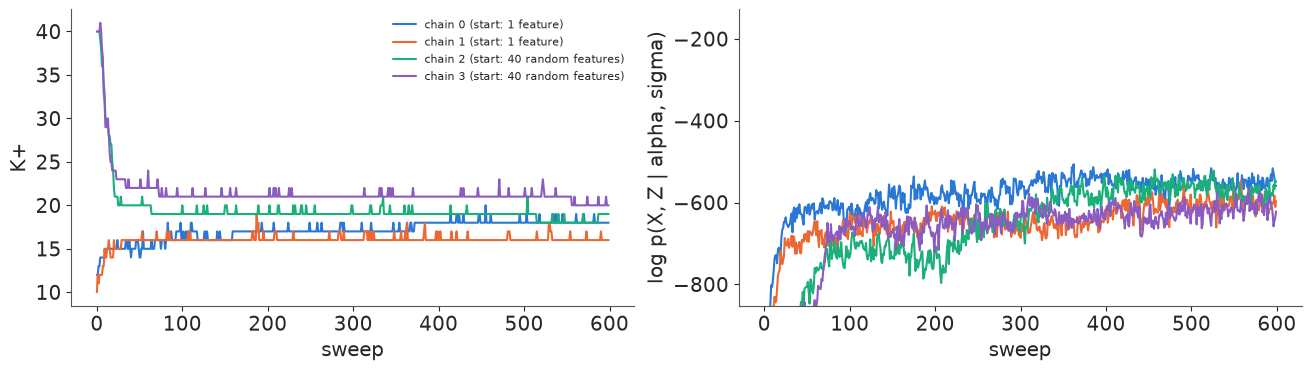

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for c in range(4):
    lab = "start: 1 feature" if c < 2 else "start: 40 random features"
    axes[0].plot(traces["K"][c], color=CHAIN_COLORS[c], label=f"chain {c} ({lab})")
    axes[1].plot(traces["logjoint"][c], color=CHAIN_COLORS[c])
axes[0].set(xlabel="sweep", ylabel="K+")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="sweep", ylabel="log p(X, Z | alpha, sigma)", ylim=(np.percentile(traces["logjoint"][:, 50:], 1) - 50, None));

The traces tell the story. Chains that start with 40 random features shed them quickly down to
19-21 and then stop: each remaining feature is owned by enough digits that switching it off,
one digit at a time, costs likelihood at every step. Chains that start with one feature grow to 16-18 and stop
too. To get from one configuration to the other, many $z_{ik}$ would have to change *together*
(two features merging into one, or one splitting into two), and a sampler that flips one entry
at a time must pass through much less likely states to do it. The log-joint panel also shows
chain 2 still climbing until about sweep 400, long after its $K_+$ has settled.

### Random split-merge moves

The textbook remedy is a move that changes many entries at once. Here is the simplest valid one,
a Metropolis-Hastings move on the multiset of columns: **merge** two random features into one
(the union of their owners), or **split** a random feature by sending each owner to the first,
the second or both halves with probability 1/3. The proposal probabilities, including the
counting of identical columns, enter the acceptance ratio. (On the three-row example above this
move also reproduces the exact posterior; we checked it while writing.) We run it for 100
sweeps, 50 proposals per sweep, on top of Gibbs from the end of chain 2.

In [16]:
def split_merge(X, Z, alpha, sx, sa, rng, n_prop=50):
    """Metropolis-Hastings on the multiset of columns: merge two random features (their union), or
    split one by sending each owner to 'first', 'second' or 'both' with probability 1/3."""
    def counts(Z):
        return Counter(Z[:, k].tobytes() for k in range(Z.shape[1]))

    def log_q_split(Zb, u, c1, c2):  # prob. of picking column u in Zb and splitting it into {c1, c2}
        K = Zb.shape[1]
        return (np.log((0.5 if K >= 2 else 1.0) * counts(Zb)[u.tobytes()] / K)
                + np.log(1 if np.array_equal(c1, c2) else 2) - u.sum() * np.log(3))

    def log_q_merge(Zs, c1, c2):  # prob. of picking an unordered pair with values {c1, c2} in Zs
        K, cnt = Zs.shape[1], counts(Zs)
        n = (cnt[c1.tobytes()] * (cnt[c1.tobytes()] - 1) / 2 if np.array_equal(c1, c2)
             else cnt[c1.tobytes()] * cnt[c2.tobytes()])
        return np.log(0.5 * n / (K * (K - 1) / 2))

    def target(Z):
        return log_ibp_prior(Z, alpha) + collapsed_loglik(X, Z, sx, sa)

    lt, acc = target(Z), {"split": 0, "merge": 0}
    for _ in range(n_prop):
        K = Z.shape[1]
        if K == 0:
            break
        if K >= 2 and rng.random() < 0.5:
            a, b = rng.choice(K, 2, replace=False)
            c1, c2 = Z[:, a], Z[:, b]
            u = c1 | c2
            Znew = np.column_stack([np.delete(Z, [a, b], axis=1), u])
            log_q = log_q_split(Znew, u, c1, c2) - log_q_merge(Z, c1, c2)
            kind = "merge"
        else:
            k = rng.integers(K)
            u, own = Z[:, k], np.flatnonzero(Z[:, k])
            lab = rng.integers(3, size=len(own))
            c1, c2 = np.zeros_like(u), np.zeros_like(u)
            c1[own[lab != 1]], c2[own[lab != 0]] = 1, 1
            if c1.sum() == 0 or c2.sum() == 0:
                continue  # an empty half: stay put (counted in q through the 3^-m)
            Znew = np.column_stack([np.delete(Z, k, axis=1), c1, c2])
            log_q = log_q_merge(Znew, c1, c2) - log_q_split(Z, u, c1, c2)
            kind = "split"
        lt_new = target(Znew)
        if np.log(rng.random()) < lt_new - lt + log_q:
            Z, lt = Znew, lt_new
            acc[kind] += 1
    return Z, acc


t0 = time.time()
Z_sm = chains[2][1][-1][0]
_, _, sa_sm, alpha_sm = chains[2][1][-1]
acc_tot, K_sm = Counter(), []
r_sm = np.random.default_rng(99)
for sweep in range(100):
    Z_sm = gibbs_sweep(X, Z_sm, alpha_sm, SX, sa_sm, r_sm)
    Z_sm, acc = split_merge(X, Z_sm, alpha_sm, SX, sa_sm, r_sm, n_prop=50)
    acc_tot.update(acc)
    K_sm.append(Z_sm.shape[1])
print(f"{time.time() - t0:.0f} s: 5000 proposals, accepted {dict(acc_tot)}; K+ from {K_sm[0]} to {K_sm[-1]}")

3 s: 5000 proposals, accepted {'split': 0, 'merge': 0}; K+ from 19 to 19


None of the 5000 proposals is accepted. A random split sends each owner of a feature to a random
half, so it almost always tears apart digits that belong together; a random merge of two
unrelated features destroys both. Useful split-merge moves allocate owners *sequentially* by how
well they fit each half (Meeds et al. 2007, in the style of Jain & Neal's for mixtures). That is
more code than this notebook can carry (see "Try it yourself"). The honest conclusion: **each of our chains describes one local mode**,
and the summaries below must say which chain they come from and check what the chains agree on.

## 6 · What was learned: label-free summaries

Features are exchangeable, so "feature 3" means nothing across draws or chains - the same
problem as component labels in E26, with an extra twist: two features that always appear
together are equivalent to one feature with their summed image, so even the *number* of
features is only weakly identified. Two summaries do not care about labels at all:

- the **shared-feature matrix** $E[Z Z^\top]$: entry $(i, j)$ is the expected number of features
  digits $i$ and $j$ have in common (the IBP's version of E26's co-clustering matrix);
- the **reconstruction** $E[Z A]$ and the predictions of section 8.

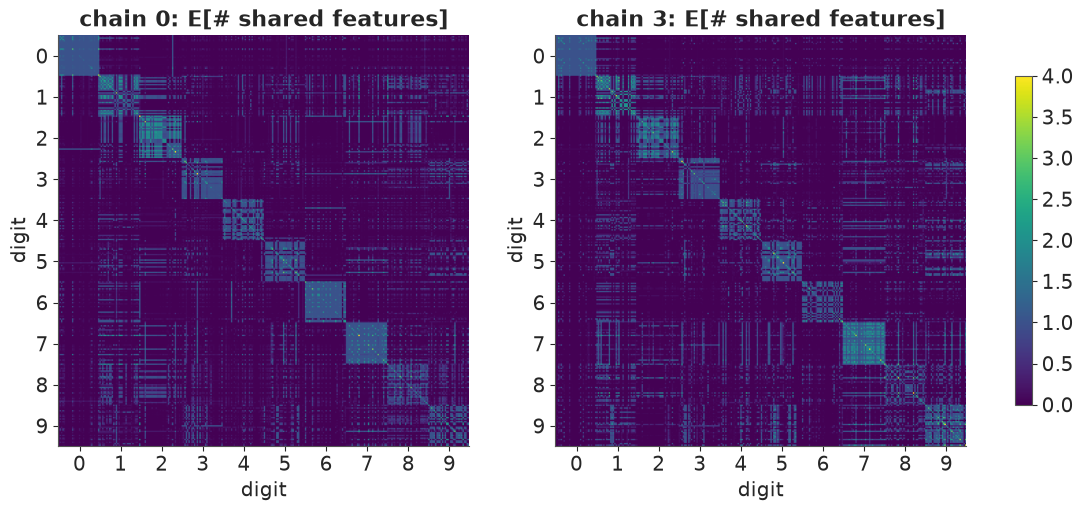

In [17]:
def feature_means(Z, sx, sa):
    Z = Z.astype(float)
    return np.linalg.solve(Z.T @ Z + (sx / sa) ** 2 * np.eye(Z.shape[1]), Z.T @ X)


order = np.argsort(digit, kind="stable")
share = [np.mean([Zk.astype(float) @ Zk.T.astype(float) for Zk, *_ in c[1]], axis=0) for c in chains]
best = int(np.argmax([traces["logjoint"][c, 200:].mean() for c in range(4)]))
worst = int(np.argmin([traces["logjoint"][c, 200:].mean() for c in range(4)]))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c in zip(axes, [best, worst]):
    im = ax.imshow(share[c][np.ix_(order, order)], cmap="viridis", vmin=0, vmax=4)
    ticks = np.arange(10) * 30 + 15
    ax.set_xticks(ticks, range(10)); ax.set_yticks(ticks, range(10))
    ax.set(title=f"chain {c}: E[# shared features]", xlabel="digit", ylabel="digit")
fig.colorbar(im, ax=axes, shrink=0.8);

Sorted by digit (which the model never saw), both chains show a block-diagonal pattern: digits of
the same class share one to two features on average, digits of different classes mostly none.
The faint off-diagonal stripes are where the IBP differs from a clustering: some digits of
different classes share a feature (the feature table below says which). The worst chain (3)
has the same blocks with more off-diagonal sharing, in different places: the modes agree on the
classes and disagree on the shared parts.

To look at features we need one labelled configuration. We take the last draw of the best chain
and show the posterior mean image of each feature, $\bar A = M^{-1} Z^\top X$, with the digit
classes that most often own it.

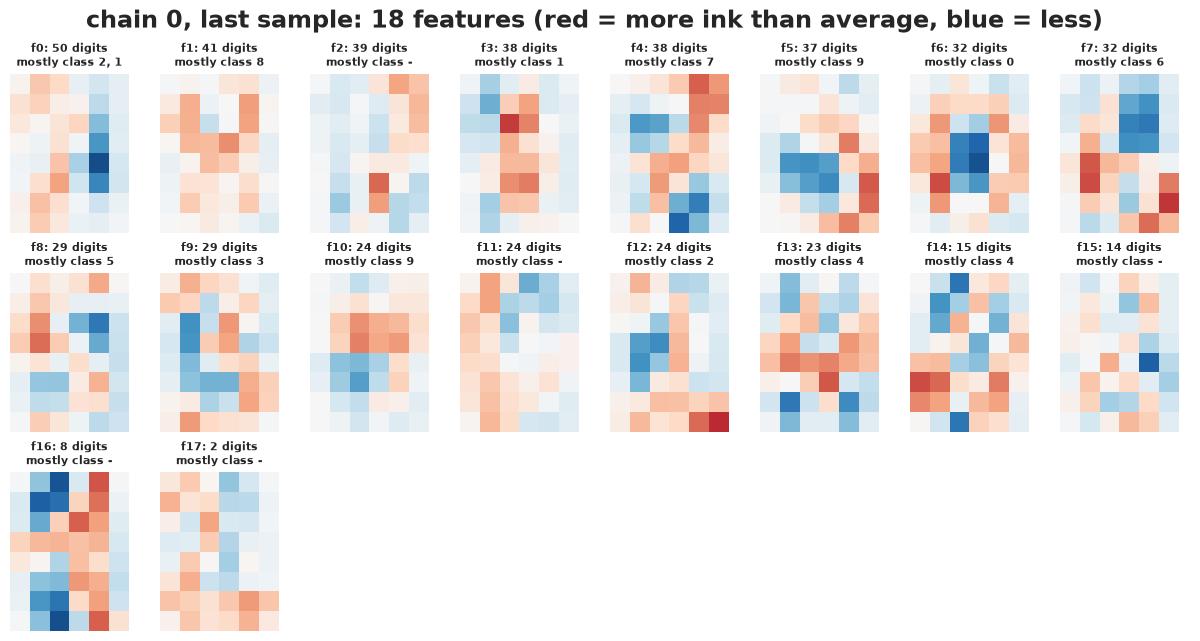

In [18]:
Zb, sxb, sab, _ = chains[best][1][-1]
A_b = feature_means(Zb, sxb, sab)
feat_order = np.argsort(-Zb.sum(0))
Kb = len(feat_order)
frac = np.array([[Zb[digit == d, k].mean() for d in range(10)] for k in feat_order])

ncol = 8
nrow = int(np.ceil(Kb / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 2.1 * nrow))
for j, ax in enumerate(axes.flat):
    ax.axis("off")
    if j < Kb:
        k = feat_order[j]
        ax.imshow(A_b[k].reshape(SHAPE), cmap="RdBu_r", vmin=-0.7, vmax=0.7)
        top = ", ".join(str(d) for d in np.argsort(-frac[j])[:3] if frac[j, d] > 0.3)
        ax.set_title(f"f{j}: {int(Zb[:, k].sum())} digits\nmostly class {top or '-'}", fontsize=8)
fig.suptitle(f"chain {best}, last sample: {Kb} features (red = more ink than average, blue = less)");

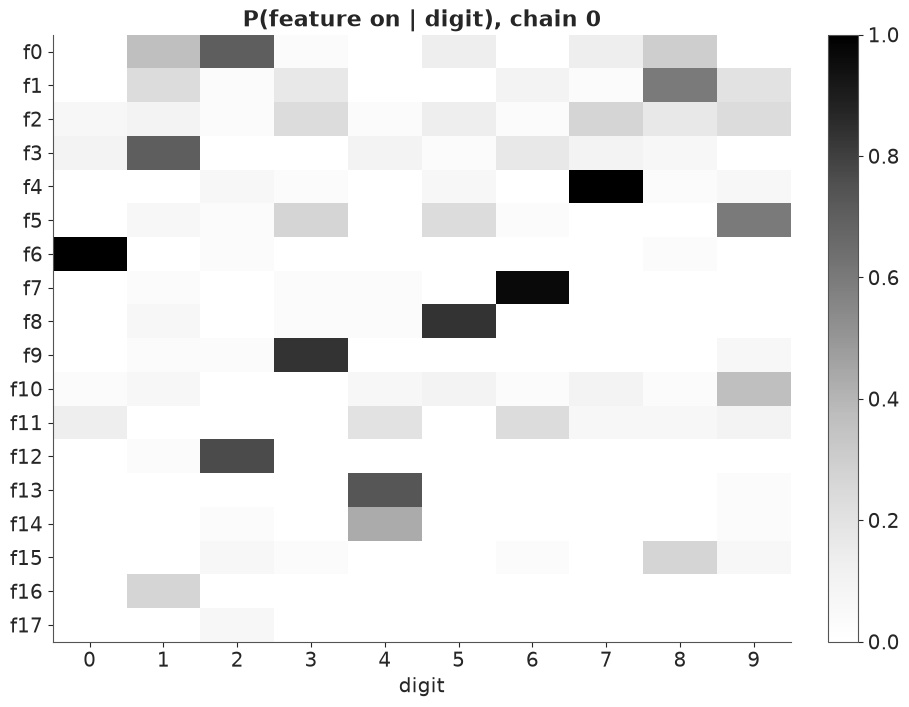

In [19]:
fig, ax = plt.subplots(figsize=(9, 0.32 * Kb + 1.2))
im = ax.imshow(frac, cmap="Greys", vmin=0, vmax=1, aspect="auto")
ax.set_yticks(range(Kb), [f"f{j}" for j in range(Kb)])
ax.set_xticks(range(10))
ax.set(xlabel="digit", title="P(feature on | digit), chain %d" % best)
fig.colorbar(im, ax=ax);

Most features are **class templates**, on for most digits of one class and almost no others: f6
for the 0s (a hollow centre), f4 for the 7s, f7 for the 6s, f8 for the 5s, f9 for the 3s, f12
for the 2s and f3 for the 1s; the 4s get two (f13, f14). A handful of features are **shared
parts**, owned by a fraction of several classes: the feature owned by most 2s is also owned by about a third of the 1s and 8s, and the
one owned by most 9s also by some 3s and 5s. The rest are small and spread thin. At this
resolution the IBP has mostly rediscovered the digit classes, as a clustering would, and added a
layer of optional, shared strokes on top. That is a fair description of handwriting in 8 x 6
pixels, and a warning not to expect the textbook "each digit = a set of strokes" picture from
real data.

How reliable is each of these features? For every one, we count the share of draws, chain by
chain, that contain a feature whose image correlates above 0.9 with it: a matching that ignores
labels.

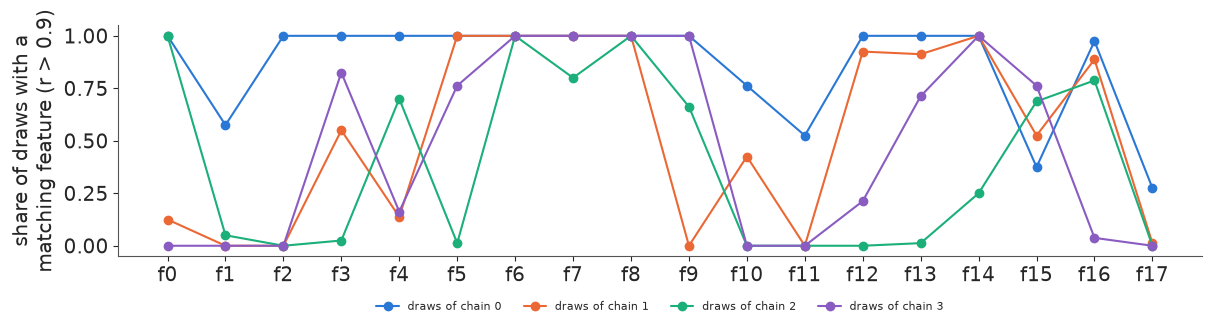

In [20]:
def match_rate(A_ref, draws, thresh=0.9):
    """For each reference feature: share of posterior draws holding a feature with corr > thresh."""
    hits = np.zeros(len(A_ref))
    for Zd, sx_d, sa_d, _ in draws:
        A_d = feature_means(Zd, sx_d, sa_d)
        C = np.corrcoef(A_ref, A_d)[: len(A_ref), len(A_ref):]
        hits += C.max(1) > thresh
    return hits / len(draws)


rates = np.array([match_rate(A_b[feat_order], c[1]) for c in chains])
fig, ax = plt.subplots(figsize=(12, 3))
for c in range(4):
    ax.plot(range(Kb), rates[c], "o-", color=CHAIN_COLORS[c], label=f"draws of chain {c}")
ax.set_xticks(range(Kb), [f"f{j}" for j in range(Kb)])
ax.set(ylabel="share of draws with a\nmatching feature (r > 0.9)", ylim=(-0.05, 1.05))
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15));

Chain 0 holds most of its own features in most of its draws (a few, such as f1, f11, f15 and
f17, come and go). The templates for 0 and 5 (f6, f8) are in every draw of every chain, and the
6-template (f7) in at least 80% of them. Beyond that it depends on the chain: the shared 2-1-8
feature f0 is in every draw of chain 2 and in almost none of chains 1 and 3; the 3-template f9
never appears in chain 1; the shared 9-3-5 feature f5 is in chains 0, 1 and 3 but not in 2.
**The modes agree on much of the class structure and disagree on the shared strokes.** Any
claim about a particular shared feature would need to survive this check.

## 7 · The same model in PyMC: truncate, then sum the binary features out

PyMC cannot sample a binary matrix with an unbounded number of columns, and its NUTS sampler
cannot sample binary entries at all. What it can do is **truncate** the stick-breaking
construction at $K$ features and **sum each row's binary vector out exactly**: with $K$ features
a row has $2^K$ possible patterns $c$, so

$$p(x_i \mid A, \pi) = \sum_{c \in \{0,1\}^K} \prod_k \pi_k^{c_k} (1-\pi_k)^{1-c_k}\;
\text{Normal}(x_i \mid c A, \sigma_X^2 I),$$

a `logsumexp` over $2^K$ terms per row. The features $A$ are now explicit parameters (the collapse
over $A$ and the sum over $Z$ cannot both be done: $p(X \mid Z)$ does not factorise over rows),
and NUTS samples $A$, the sticks $\nu$, $\alpha$ and $\sigma_A$. We keep $\sigma_X = 0.25$ and
take $K = 8$: 256 patterns per row. The model is a `pm.Potential`, so the per-row log-likelihood
is recomputed in NumPy where needed.

In [21]:
def ibp_pymc(X, K, sx=SX):
    """Stick-breaking IBP truncated at K features; every row's z summed over all 2^K patterns."""
    C = np.array(list(itertools.product([0, 1], repeat=K)), float)  # 2^K x K patterns
    Xt = pt.as_tensor(X)
    with pm.Model(coords={"feature": range(K), "pixel": range(X.shape[1])}) as m:
        alpha = pm.Gamma("alpha", 1.0, 1.0)
        nu = pm.Beta("nu", alpha, 1.0, dims="feature")
        logpi = pm.Deterministic("logpi", pt.cumsum(pt.log(nu)), dims="feature")
        sa = pm.HalfNormal("sigma_A", 1.0)
        A = pm.Normal("A", 0.0, sa, dims=("feature", "pixel"))
        means = pt.dot(C, A)  # 2^K x D: every pattern's image
        sq = (Xt**2).sum(1)[:, None] - 2 * pt.dot(Xt, means.T) + (means**2).sum(1)[None, :]
        log_prior_z = pt.dot(C, logpi) + pt.dot(1 - C, pt.log1mexp(logpi))
        ll_rows = (pt.logsumexp(log_prior_z[None, :] - sq / (2 * sx**2), axis=1)
                   - 0.5 * X.shape[1] * np.log(2 * np.pi * sx**2))
        pm.Potential("loglik", ll_rows.sum())
    return m, C


m8, C8 = ibp_pymc(X, 8)
t0 = time.time()
with m8:
    idata_default = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"{time.time() - t0:.0f} s")
print("mean model logp per chain:", idata_default.sample_stats["logp"].mean("draw").to_numpy().round(0))
print("pi_1 per chain:", np.exp(idata_default.posterior["logpi"].isel(feature=0).mean("draw")).to_numpy().round(3))

27 s
mean model logp per chain: [ -158.  -120. -5167. -4653.]
pi_1 per chain: [0.431 0.384 0.    0.   ]


Two of the four chains end with a model log density around -5000, against -120 to -160 for the
other two, and their first feature probability is 0: **every feature switched off**. This is a
trap, not a mode. Early in warm-up the randomly initialised features explain nothing, so the
likelihood pushes the $\pi_k$ down; once every $\pi_k$ is near zero, no row uses any feature,
the features receive no gradient from the data, and nothing pushes $\pi$ back up. The log density
of "no features" is thousands of units worse, but NUTS only follows local gradients.

The fix is a start in the right basin: features initialised at half of eight random (centred)
digits, $\nu_k = 0.8$, and nutpie's start jitter switched off so that every chain starts there
(a *list* of per-chain `initvals` would silently switch to PyMC's own NUTS). We also give
warm-up 1000 steps.

In [22]:
A0 = 0.5 * X[rng.choice(N, 8, replace=False)]
t0 = time.time()
with m8:
    idata8 = pm.sample(random_seed=RANDOM_SEED, progressbar=False, tune=1000,
                       initvals={"A": A0, "nu": np.full(8, 0.8), "sigma_A": 0.3, "alpha": 2.0},
                       compile_kwargs={"jitter_rvs": set()})
print(f"{time.time() - t0:.0f} s, divergences per chain:",
      idata8.sample_stats["diverging"].sum("draw").to_numpy())
print("mean model logp per chain:", idata8.sample_stats["logp"].mean("draw").to_numpy().round(0))
az.summary(idata8, var_names=["alpha", "sigma_A", "logpi"], round_to=2)

44 s, divergences per chain: [0 0 0 0]
mean model logp per chain: [-61. -53. -51. -80.]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,4.19,1.43,2.19,6.76,6433.98,2965.00,1.00,0.02,0.03
sigma_A,0.16,0.01,0.15,0.17,41.93,89.71,1.07,0.00,0.00
logpi[0],-0.69,0.12,-0.87,-0.50,5.57,11.17,1.93,0.05,0.02
logpi[1],-0.78,0.14,-0.96,-0.57,5.56,11.58,1.93,0.07,0.01
logpi[2],-0.86,0.11,-1.00,-0.67,6.25,18.82,1.70,0.05,0.01
logpi[3],-0.92,0.07,-1.02,-0.80,8.43,33.09,1.40,0.03,0.00
logpi[4],-0.96,0.06,-1.05,-0.85,9.05,13.16,1.35,0.02,0.01
logpi[5],-0.98,0.06,-1.07,-0.88,10.37,14.50,1.29,0.02,0.01
logpi[6],-1.07,0.07,-1.20,-0.97,11.67,15.17,1.25,0.02,0.01
logpi[7],-1.15,0.08,-1.29,-1.04,17.12,36.08,1.15,0.02,0.01


No chain collapses and there are no divergences, but the chains still disagree: their mean log
densities range from about -50 to -80, the $\pi_k$ have $\hat R$ between 1.15 and 1.9 and bulk
ESS between 6 and 17. Only $\alpha$ ($\hat R = 1.00$), which depends on the sticks as a group,
and $\sigma_A$ (1.07) look healthy. With $Z$ summed out, the posterior over the continuous $A$
is as multimodal as a mixture model's (E26): NUTS is exact within a mode and local, just like
the Gibbs sampler.

In [23]:
pi8 = np.exp(idata8.posterior["logpi"])
print("posterior mean of pi_k by chain:\n", pi8.mean("draw").to_numpy().round(2))

posterior mean of pi_k by chain:
 [[0.58 0.54 0.44 0.41 0.38 0.37 0.35 0.32]
 [0.52 0.5  0.49 0.42 0.41 0.4  0.32 0.3 ]
 [0.44 0.41 0.39 0.38 0.37 0.37 0.35 0.32]
 [0.47 0.4  0.39 0.38 0.37 0.37 0.36 0.33]]


The truncation check fails in every chain. The last stick $\pi_8$ has a posterior mean of 0.30
to 0.33: a ninth feature would have been owned by nearly a third of the digits, not by nobody.
The Gibbs sampler found 16 to 21 features at the same $\sigma_X$, and 8 is simply too few.

$Z$ itself is recovered after sampling: for each posterior draw, the posterior over the 256
patterns of each row is available in closed form, and we sample one.

occupied features among the 8, over 200 draws: Counter({8: 200})


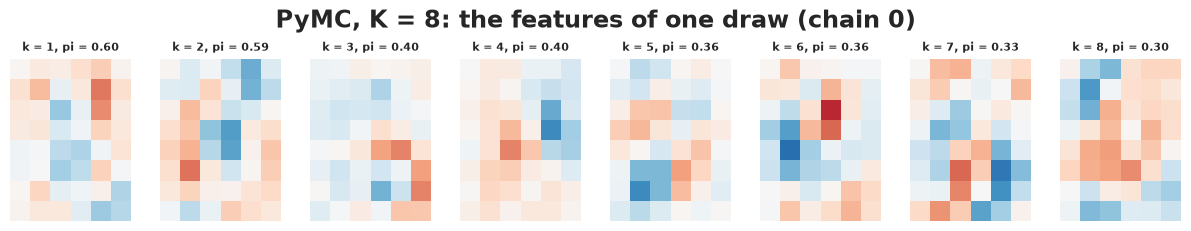

In [24]:
# recover Z: for each draw, the posterior over the 256 patterns of every row
post8 = az.extract(idata8, var_names=["A", "logpi"], num_samples=200, random_seed=RANDOM_SEED)


def pattern_logpost(Xr, A, logpi, C, sx=SX):
    means = C @ A
    sq = (Xr**2).sum(1)[:, None] - 2 * Xr @ means.T + (means**2).sum(1)[None, :]
    lp = C @ logpi + (1 - C) @ np.log(-np.expm1(logpi))
    return lp[None, :] - sq / (2 * sx**2)


r = np.random.default_rng(3)
Kp8 = []
for s in range(200):
    A_s = post8["A"].isel(sample=s).to_numpy()
    lpp = pattern_logpost(X, A_s, post8["logpi"].isel(sample=s).to_numpy(), C8)
    prob = np.exp(lpp - logsumexp(lpp, axis=1, keepdims=True))
    pick = (prob.cumsum(1) > r.random((N, 1))).argmax(1)
    Kp8.append(int((C8[pick].sum(0) > 0).sum()))
print("occupied features among the 8, over 200 draws:", Counter(Kp8))

A_last = idata8.posterior["A"].isel(chain=0, draw=-1).to_numpy()
fig, axes = plt.subplots(1, 8, figsize=(12, 2.2))
for k, ax in enumerate(axes):
    ax.imshow(A_last[k].reshape(SHAPE), cmap="RdBu_r", vmin=-0.7, vmax=0.7)
    ax.set_title(f"k = {k + 1}, pi = {float(pi8.isel(chain=0, draw=-1, feature=k)):.2f}", fontsize=8)
    ax.axis("off")
fig.suptitle("PyMC, K = 8: the features of one draw (chain 0)");

All 8 features are used in every draw. With too few features, each one has to do more work: in
the draw shown, every feature is owned by 30-60% of the digits, whereas no Gibbs feature above is
owned by more than a sixth. Eight features cannot be ten class templates, so they become broad
corrections shared across classes.

Why not simply take $K = 16$? The cost of one gradient grows with the $2^K$ patterns:

In [25]:
def time_logp(K):
    m, _ = ibp_pymc(X, K)
    f = m.compile_logp()
    g = m.compile_dlogp()
    ip = m.initial_point()
    f(ip); g(ip)
    t0 = time.time()
    for _ in range(20):
        g(ip)
    return (time.time() - t0) / 20


for K in [4, 8, 10, 12]:
    print(f"K = {K:2d}: {2 ** K:5d} patterns per row, gradient {1000 * time_logp(K):6.1f} ms")

K =  4:    16 patterns per row, gradient    0.1 ms


K =  8:   256 patterns per row, gradient    0.8 ms


K = 10:  1024 patterns per row, gradient    3.9 ms


K = 12:  4096 patterns per row, gradient   16.5 ms


Each extra feature roughly doubles the cost. The timings vary with the machine and its load (by
up to a factor of two between our builds), but a gradient at $K = 12$ always cost about 20 times
one at $K = 8$, so the $K = 8$ fit that took under a minute would take 15-20 minutes at $K = 12$
and hours at $K = 16$,
and memory grows the same way ($N \times 2^K$ numbers per intermediate). **Exact enumeration is
for $K \lesssim 10$.** It is the right tool when the number of features is small and known to be
small; it cannot deliver the "unbounded" in the IBP. The collapsed Gibbs sampler handles 90
features, at the price of mixing badly.

## 8 · Checking the model: PPC and held-out digits

### Posterior predictive check

Replicated data sets from the best Gibbs chain: $A$ drawn from its Gaussian posterior given $Z$,
then $Z A$ plus noise, plus the average digit.

negative ink in replicates: 17% of pixels


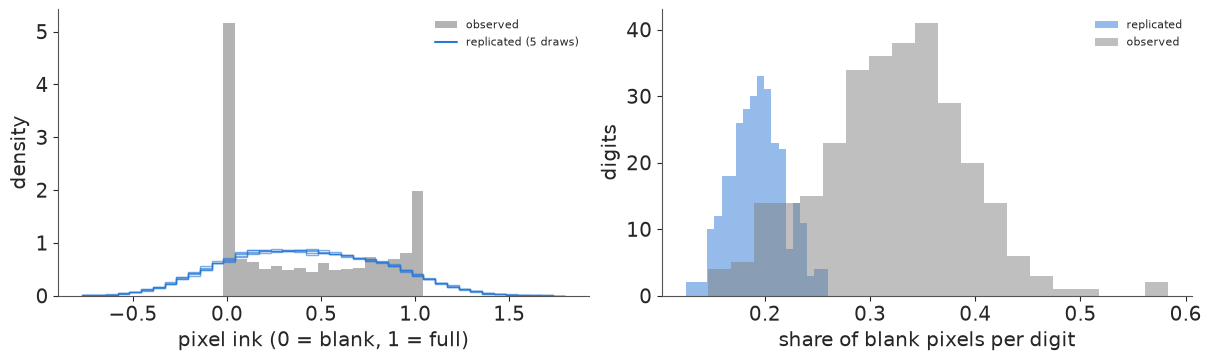

In [26]:
# posterior predictive replicates from the best Gibbs chain: A from its posterior, then noise
def draw_A(Z, sx, sa, rng):
    Z = Z.astype(float)
    Minv = np.linalg.inv(Z.T @ Z + (sx / sa) ** 2 * np.eye(Z.shape[1]))
    return Minv @ Z.T @ X + np.linalg.cholesky(sx**2 * Minv) @ rng.normal(size=(Z.shape[1], D))


r = np.random.default_rng(4)
reps = []
for Zd, sx_d, sa_d, _ in chains[best][1][::8]:
    reps.append(Zd @ draw_A(Zd, sx_d, sa_d, r) + sx_d * r.normal(size=X.shape) + mu)
reps = np.array(reps)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
bins = np.arange(-0.8, 1.8, 1 / 16) + 1 / 32  # observed values sit on multiples of 1/16
axes[0].hist(Xraw.ravel(), bins=bins, density=True, color="0.7", label="observed")
for rp in reps[:5]:
    axes[0].hist(rp.ravel(), bins=bins, density=True, histtype="step", color=BLUE, alpha=0.6)
axes[0].plot([], [], color=BLUE, label="replicated (5 draws)")
axes[0].set(xlabel="pixel ink (0 = blank, 1 = full)", ylabel="density")
axes[0].legend(fontsize=8)
stat_obs = (Xraw < 1 / 32).mean(1)  # less than half a count of ink
stat_rep = (reps < 1 / 32).mean(2)
axes[1].hist(stat_rep.mean(0), bins=20, color=BLUE, alpha=0.5, label="replicated")
axes[1].hist(stat_obs, bins=20, color="0.5", alpha=0.5, label="observed")
axes[1].set(xlabel="share of blank pixels per digit", ylabel="digits")
axes[1].legend(fontsize=8)
print(f"negative ink in replicates: {(reps < 0).mean():.0%} of pixels")

The PPC finds a real misfit. Real ink counts have a spike at exactly 0 (a third of all pixels are
blank) and a smaller one at full ink; the replicated pixels form one smooth hump, 17% of them are
*negative ink*, and the replicated digits have far fewer blank pixels than real ones. The model's
noise is Gaussian, homoscedastic and unbounded, and the data are bounded counts whose variability
depends strongly on the pixel. The model is a description of structure at a chosen resolution,
not a generative model of ink.

### Held-out writers: complete the bottom half

The practical test: show each model the **top half** of a digit written by one of the 13 test
writers, and ask for the **bottom half**. We score the log predictive density
$\log p(x_\text{bottom} \mid x_\text{top})$ per digit (24 pixels) and the RMSE of the predicted
mean.

- **IBP (Gibbs):** for each of 20 posterior draws per chain, draw $A$ from its posterior, run a
  short Gibbs sampler for the test digit's features given the top half (prior $m_k / (N+1)$ per
  feature; brand-new features, with prior mass about $\alpha / N \approx 0.01$ per digit, are
  ignored), and average $p(x_\text{bottom} \mid z)$ over it.
- **IBP (PyMC, $K = 8$):** exact: sum over the 256 patterns weighted by their posterior given the
  top half, for 200 draws.
- **Baselines:** probabilistic PCA (the maximum-likelihood linear-Gaussian model with $q$
  continuous factors, the non-Bayesian cousin of E22's factor model) and a full-covariance
  Gaussian, both conditioned in closed form.

In [27]:
top, bottom = np.arange(24), np.arange(24, 48)  # rows 0-3 and 4-7 of the 8 x 6 image


def heldout_gibbs(draws, Xt, rng, n_sweeps=25, burn=5):
    """log p(bottom | top) per test digit for Gibbs draws: A from its posterior per draw, z* by
    Gibbs given the top half (all test digits at once), p(bottom | z*) averaged."""
    ll, pred = [], []
    xv, xh = Xt[:, top], Xt[:, bottom]
    for Zd, sx_d, sa_d, _ in draws:
        A = draw_A(Zd, sx_d, sa_d, rng)
        Av, Ah = A[:, top], A[:, bottom]
        logit_prior = np.log(Zd.sum(0) / (N + 1)) - np.log1p(-Zd.sum(0) / (N + 1))
        z = (rng.random((len(Xt), A.shape[0])) < Zd.mean(0)).astype(float)
        mv = z @ Av
        for t in range(n_sweeps):
            for k in range(A.shape[0]):
                base = mv - z[:, [k]] * Av[k]
                d = (np.sum((xv - base) ** 2, 1) - np.sum((xv - base - Av[k]) ** 2, 1)) / (2 * sx_d**2)
                z[:, k] = rng.random(len(Xt)) < 1 / (1 + np.exp(-(d + logit_prior[k])))
                mv = base + z[:, [k]] * Av[k]
            if t >= burn:
                mh = z @ Ah
                ll.append(stats.norm(mh, sx_d).logpdf(xh).sum(1))
                pred.append(mh)
    ll = np.array(ll)
    return logsumexp(ll, axis=0) - np.log(len(ll)), np.mean(pred, axis=0)


def heldout_pymc(post, C, Xt):
    ll, pred = [], []
    for s in range(post.sizes["sample"]):
        A = post["A"].isel(sample=s).to_numpy()
        logpi = post["logpi"].isel(sample=s).to_numpy()
        lpv = pattern_logpost(Xt[:, top], A[:, top], logpi, C) - 0.5 * len(top) * np.log(2 * np.pi * SX**2)
        w = np.exp(lpv - logsumexp(lpv, axis=1, keepdims=True))  # p(pattern | top half)
        mh = C @ A[:, bottom]
        llh = (-0.5 * ((Xt[:, None, bottom] - mh[None]) ** 2).sum(2) / SX**2
               - 0.5 * len(bottom) * np.log(2 * np.pi * SX**2))
        ll.append(logsumexp(np.log(w + 1e-300) + llh, axis=1))
        pred.append(w @ mh)
    ll = np.array(ll)
    return logsumexp(ll, axis=0) - np.log(len(ll)), np.mean(pred, axis=0)


def heldout_gauss(S, Xt):
    """Conditional Gaussian bottom | top under covariance S (mean 0 after centring)."""
    Svv, Shv, Shh = S[np.ix_(top, top)], S[np.ix_(bottom, top)], S[np.ix_(bottom, bottom)]
    Kg = Shv @ np.linalg.inv(Svv)
    mean = Xt[:, top] @ Kg.T
    cov = Shh - Kg @ Shv.T
    return stats.multivariate_normal(np.zeros(len(bottom)), cov).logpdf(Xt[:, bottom] - mean), mean


def ppca_cov(X, q):
    S = np.cov(X.T, bias=True)
    lam, U = np.linalg.eigh(S)
    lam, U = lam[::-1], U[:, ::-1]
    s2 = lam[q:].mean()
    W = U[:, :q] * np.sqrt(lam[:q] - s2)
    return W @ W.T + s2 * np.eye(X.shape[1])


t0 = time.time()
results = {}
r = np.random.default_rng(5)
for c in range(4):
    results[f"IBP Gibbs, chain {c} (sigma_X = 0.25)"] = heldout_gibbs(chains[c][1][::4], X_test, r)
results["IBP Gibbs, everything free"] = heldout_gibbs(kept_free[::2], X_test, r)
results["IBP PyMC, K = 8 (sigma_X = 0.25)"] = heldout_pymc(post8, C8, X_test)
for q in [5, 10, 20]:
    results[f"probabilistic PCA, q = {q}"] = heldout_gauss(ppca_cov(X, q), X_test)
results["full-covariance Gaussian"] = heldout_gauss(np.cov(X.T, bias=True), X_test)
print(f"{time.time() - t0:.0f} s")
ref = results["probabilistic PCA, q = 10"][0]
for name, (ll, pred) in results.items():
    diff = ll - ref
    rmse = np.sqrt(np.mean((pred - X_test[:, bottom]) ** 2))
    print(f"{name:40s} log p(bottom | top) per digit {ll.mean():6.1f}   "
          f"vs PPCA-10 {diff.mean():+6.1f} (se {diff.std() / np.sqrt(len(diff)):.1f})   RMSE {rmse:.3f}")

3 s
IBP Gibbs, chain 0 (sigma_X = 0.25)      log p(bottom | top) per digit    0.7   vs PPCA-10   +0.6 (se 0.3)   RMSE 0.264
IBP Gibbs, chain 1 (sigma_X = 0.25)      log p(bottom | top) per digit    0.5   vs PPCA-10   +0.4 (se 0.3)   RMSE 0.267
IBP Gibbs, chain 2 (sigma_X = 0.25)      log p(bottom | top) per digit    0.9   vs PPCA-10   +0.8 (se 0.3)   RMSE 0.264
IBP Gibbs, chain 3 (sigma_X = 0.25)      log p(bottom | top) per digit    0.7   vs PPCA-10   +0.5 (se 0.3)   RMSE 0.266
IBP Gibbs, everything free               log p(bottom | top) per digit  -27.8   vs PPCA-10  -28.0 (se 1.7)   RMSE 0.281
IBP PyMC, K = 8 (sigma_X = 0.25)         log p(bottom | top) per digit   -0.3   vs PPCA-10   -0.5 (se 0.3)   RMSE 0.283
probabilistic PCA, q = 5                 log p(bottom | top) per digit   -2.2   vs PPCA-10   -2.3 (se 0.3)   RMSE 0.307
probabilistic PCA, q = 10                log p(bottom | top) per digit    0.1   vs PPCA-10   +0.0 (se 0.0)   RMSE 0.291
probabilistic PCA, q = 20           

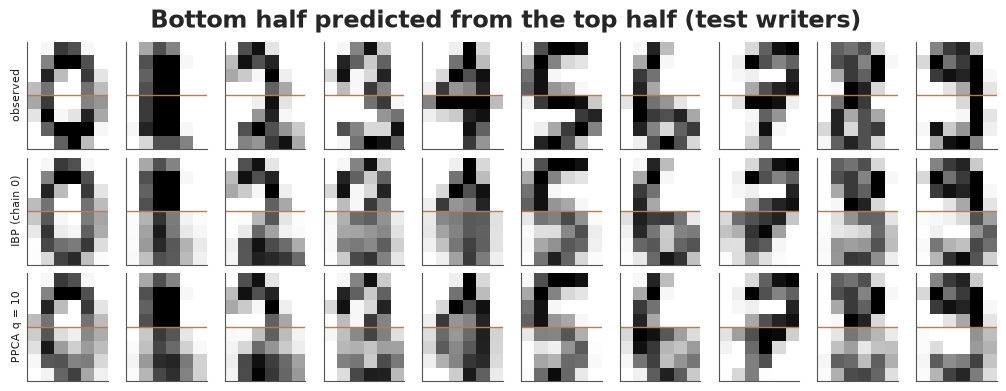

In [28]:
show = [np.flatnonzero(digit_test == d)[0] for d in range(10)]
rows = [("observed", X_test + mu),
        ("IBP (chain %d)" % best, np.hstack([X_test[:, top], results[f"IBP Gibbs, chain {best} (sigma_X = 0.25)"][1]]) + mu),
        ("PPCA q = 10", np.hstack([X_test[:, top], results["probabilistic PCA, q = 10"][1]]) + mu)]
fig, axes = plt.subplots(3, 10, figsize=(10, 3.8))
for i, (lab, imgs) in enumerate(rows):
    for j, t in enumerate(show):
        ax = axes[i, j]
        ax.imshow(imgs[t].reshape(SHAPE), cmap="Greys", vmin=0, vmax=1)
        ax.axhline(3.5, color=ORANGE, lw=1)
        ax.set_xticks([]); ax.set_yticks([])
    axes[i, 0].set_ylabel(lab, fontsize=8)
fig.suptitle("Bottom half predicted from the top half (test writers)");

Three results, each worth stating plainly.

1. **The IBP gives the best point predictions.** All four Gibbs chains have an RMSE of 0.26-0.27
   on the hidden half, below every Gaussian baseline (0.275-0.31) and below the truncated PyMC
   model (0.28). Binary features snap a half-seen digit to a whole template, which is what a
   completion needs.
2. **It does not give the best predictive density.** At about +0.6 nats per digit over PPCA with
   10 factors, the IBP chains sit between PPCA-10 and PPCA-20, and the full-covariance Gaussian
   beats them by about 4 nats per digit. The IBP uses one noise level for all 48 pixels, while
   their spread varies a lot (the column sds in section 1 run from 0.17 to 0.38); a covariance
   matrix learns pixel-specific variances and correlations. That is the PPC's misfit, now with a
   price in nats.
3. **"Everything free" is not just uninterpretable, it is overfitted.** With 90 features and
   $\sigma_X = 0.10$ its RMSE (0.28) is similar, but its log predictive density is about 28 nats
   per digit *worse* than PPCA's: the noise level learned on the training writers is far too
   confident for new writers. Choosing the resolution was not only an aesthetic decision.

The four Gibbs chains, despite their different $K_+$ and log joints, predict within half a nat
per digit of each other (standard errors about 0.3): the local modes predict almost equally well.
That is the practical consolation for a sampler that does not mix.

## Take-aways

- The IBP is the prior for "each unit owns a set of shared features": $K_+ \sim
  \text{Poisson}(\alpha H_N)$, Poisson($\alpha$) features per row. Stick-breaking and the finite
  beta-Bernoulli model are the same process, and the ones a PyMC model can use.
- In the linear-Gaussian model the **noise level decides the number of features**, far more than
  $\alpha$. Left free, it shrinks while features multiply (90 and counting here), and held-out
  density shows that as overfitting. Choose the resolution and say why.
- A collapsed Gibbs sampler is short and fast with rank-one updates, and it is easy to get subtly
  wrong: test it against enumeration on a tiny problem.
- Gibbs over a binary matrix gets **stuck**: chains disagree on $K_+$ (16 to 21) and on the log
  joint by tens of units, and random split-merge moves are never accepted. Run several chains
  from different starts, diagnose label-free quantities, and report what the chains agree on.
- Summaries must be label-free: $K_+$, the log joint, $E[ZZ^\top]$, feature matching across draws,
  predictions. On these digits the class templates are robust and the shared strokes are not.
- Summing $Z$ out makes the model NUTS-friendly but exponential in $K$ ($K \lesssim 10$), the
  truncation bites, the posterior over $A$ is still multimodal, and a bad start collapses to "no
  features at all".

## Try it yourself

1. **Pixel-specific noise.** Give each pixel its own $\sigma_d$ in the PyMC model (the sum over
   patterns still works; the Gibbs collapse does not, because $M$ is no longer shared across
   pixels). Does the held-out density close the gap to the full-covariance Gaussian, and does
   the truncation at $K = 8$ bite less?
2. **Smarter split-merge.** Replace the random split by a sequential allocation: choose two
   digits that share a feature, seed the two halves with them, and assign the other owners one by
   one with probabilities from the collapsed likelihood, keeping track of the proposal probability
   for the reverse move. Is anything accepted now, and do the four chains get closer in $K_+$?
3. **Finite beta-Bernoulli in PyMC.** Replace the stick-breaking sticks by independent
   $\pi_k \sim \text{Beta}(\alpha / K, 1)$. The features lose their decreasing order: what happens
   to $\hat R$ of the $\pi_k$ within one chain, and how would you now check the truncation?